# Ovrlpy applied to vizgen receptor data map



In [1]:
%matplotlib inline

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import ovrlpy
import pandas as pd
import polars as pl
from matplotlib_scalebar.scalebar import ScaleBar

/dh-projects/ag-ishaque/analysis/muellni/envs/ovrlpy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import sys

import matplotlib

sys.path.append("../..")

from ovrlpy._plotting import BIH_CMAP as cmap
from ovrlpy._plotting import _plot_signal_integrity

from utils import CM, FONT, save_kwargs

matplotlib.rc("font", **FONT)

In [4]:
out_dir = Path("./figures")
out_dir.mkdir(exist_ok=True)

In [5]:
import pickle

with open("../merscope_brain.pickle", "rb") as file:
    brain = pickle.load(file)

coordinate_df = brain.transcripts.to_pandas()

In [6]:
# crop out a central part of the tissue to create artificial overlaps:
xb_, yb_ = 4100 / 2 * 3, 3100 / 2 * 3
xt_, yt_ = 2700 / 2 * 3, 400 / 2 * 3

width = 501

_xb = xb_ + width
_xt = xt_ + width
_yb = yb_ + width
_yt = yt_ + width

fold_bottom_mask = coordinate_df.x.between(xb_, _xb) & coordinate_df.y.between(yb_, _yb)
fold_top_mask = coordinate_df.x.between(xt_, _xt) & coordinate_df.y.between(yt_, _yt)

fold_df_bottom = coordinate_df[fold_bottom_mask].copy()
fold_df_bottom["fold"] = "bottom"
fold_df_top = coordinate_df[fold_top_mask].copy()
fold_df_top["fold"] = "top"

In [7]:
# move the signal to origin
fold_df_bottom.x -= xb_
fold_df_top.x -= xt_

fold_df_bottom.y -= yb_
fold_df_top.y -= yt_

fold_df_folded = fold_df_bottom.copy()
fold_df_folded.z -= fold_df_bottom.z.max() - fold_df_top.z.min()
fold_df_folded = pd.concat([fold_df_folded, fold_df_top])

In [8]:
brain.transcripts = pl.from_pandas(fold_df_bottom)
# brain.KDE_bandwidth = 2.5

brain.process_coordinates(shift=False)
brain.compute_VSI()

coherence_bottom = brain.integrity_map.copy()
signal_bottom = brain.signal_map.copy()

100%|██████████| 4/4 [00:03<00:00,  1.06it/s]


In [9]:
brain.transcripts = pl.from_pandas(fold_df_top)
# brain.KDE_bandwidth = 1

brain.process_coordinates(shift=False)
brain.compute_VSI()

coherence_top = brain.integrity_map.copy()
signal_top = brain.signal_map.copy()

100%|██████████| 4/4 [00:03<00:00,  1.05it/s]


In [10]:
brain.transcripts = pl.from_pandas(fold_df_folded)
# brain.KDE_bandwidth = 1

brain.process_coordinates(shift=False)
brain.compute_VSI()

coherence_folded = brain.integrity_map.copy()
signal_folded = brain.signal_map.copy()

100%|██████████| 4/4 [00:04<00:00,  1.00s/it]


In [11]:
def plot_purity_distribution(coherence, density=None, ax=None):
    if ax is None:
        ax = plt.gca()
    vals, bins = np.histogram(coherence, bins=50, range=(0, 1), density=density)
    colors = cmap(bins[1:-1])
    bars = ax.bar(bins[1:-1], vals[1:], width=0.01)
    for i, bar in enumerate(bars):
        bar.set_color(colors[i])

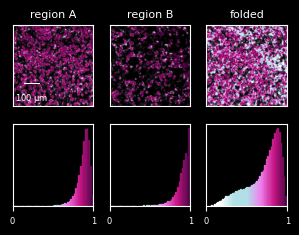

In [12]:
t = 2

title_kwargs = dict(fontsize=8)

with plt.style.context("dark_background"):
    fig, axs = plt.subplots(2, 3, figsize=(9 * CM, 6 * CM))

    axs[0, 0].set_title("region A", fontdict=title_kwargs)
    _plot_signal_integrity(axs[0, 0], coherence_top, signal_top, t)

    plot_purity_distribution(coherence_top[signal_top > t], ax=axs[1, 0])

    axs[0, 1].set_title("region B", fontdict=title_kwargs)
    _plot_signal_integrity(axs[0, 1], coherence_bottom, signal_bottom, t)

    plot_purity_distribution(coherence_bottom[signal_bottom > t], ax=axs[1, 1])

    axs[0, 2].set_title("folded", fontdict=title_kwargs)
    _plot_signal_integrity(axs[0, 2], coherence_folded, signal_folded, t)

    plot_purity_distribution(coherence_folded[signal_folded > t], ax=axs[1, 2])

    for ax in axs[0, :]:
        ax.set(xticks=[], yticks=[])
    for ax in axs[1, :]:
        ax.set(xticks=[0, 1], xlim=(0, 1), yticks=[])

    axs[0, 0].add_artist(
        ScaleBar(
            1,
            units="um",
            length_fraction=0.2,
            loc="lower left",
            frameon=False,
            color="w",
        )
    )

    fig.savefig(out_dir / "purity_summary.svg", **save_kwargs)

/tmp/ipykernel_51583/2964126930.py:10: RuntimeWarning: invalid value encountered in divide
  hist_ratio = 2 * hist_folded / (hist_top + hist_bot)


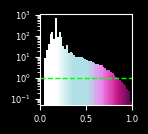

In [13]:
nbins = 50
lim = (0, 1)

hist_kwargs = dict(bins=nbins, range=lim, density=True)

hist_top, _ = np.histogram(coherence_top[signal_top > t], **hist_kwargs)
hist_bot, _ = np.histogram(coherence_bottom[signal_bottom > t], **hist_kwargs)
hist_folded, bins = np.histogram(coherence_folded[signal_folded > t], **hist_kwargs)

hist_ratio = 2 * hist_folded / (hist_top + hist_bot)

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(3 * CM, 3 * CM))

    bars = ax.bar(bins[:-1], hist_ratio, width=1 / nbins, align="edge", lw=0)
    for bar, color in zip(bars, cmap(bins[:-1])):
        bar.set_color(color)

    ax.set(yscale="log", xlim=lim)
    ax.hlines(1, 0, 1, linestyles="dashed", color="lime", lw=1)

    fig.savefig(out_dir / "purity_quotient.svg", **save_kwargs)

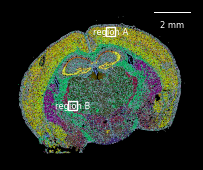

In [15]:
with plt.style.context("dark_background"):
    scatter_kwargs = dict(s=1, lw=0)

    fig, ax = plt.subplots(figsize=(6 * CM, 6 * CM))
    _ = ovrlpy.plot_tissue(
        brain,
        scalebar=dict(dx=1, units="um", frameon=False, color="w"),
        ax=ax,
        **scatter_kwargs,
    )
    ax.set_axis_off()
    ax.collections[0].set_rasterized(True)

    color = "white"
    text_kwargs = dict(color=color, fontsize=6, va="bottom", ha="center")

    rect_top = plt.Rectangle(
        (xt_, yt_), _xt - xt_, _yt - yt_, edgecolor=color, facecolor="none"
    )
    ax.add_artist(rect_top)
    ax.text((xt_ + _xt) / 2, _yt, "region A", **text_kwargs)

    rect_bottom = plt.Rectangle(
        (xb_, yb_), _xb - xb_, _yb - yb_, edgecolor=color, facecolor="none"
    )
    ax.add_artist(rect_bottom)
    ax.text((xb_ + _xb) / 2, _yb, "region B", **text_kwargs)
    ax.invert_xaxis()
    ax.invert_yaxis()

    fig.savefig(out_dir / "localmaxima.svg", **save_kwargs)